# Deploy Phoenix 1.0 from AWS Marketplace 

Leonardo AI’s Phoenix 1.0 is a next‑generation image model engineered for wide-range of styles and precise prompt adherence. Phoenix 1.0 helps creators produce on‑brand visuals for marketing, concept art, product renders, and more.

This sample notebook shows you how to deploy the Phoenix 1.0 using Amazon SageMaker:

> **Note**: This is a reference notebook and it cannot run unless you make changes suggested in the notebook.

## Pre-requisites:
1. **Note**: This notebook contains elements which render correctly in Jupyter interface. Open this notebook from an Amazon SageMaker Notebook Instance or Amazon SageMaker Studio.
1. Create an IAM role with **AmazonSageMakerFullAccess** policy attached.
1. To deploy this ML model successfully, ensure that:
    1. Either your IAM role has these three permissions and you have authority to make AWS Marketplace subscriptions in the AWS account used: 
        1. **aws-marketplace:ViewSubscriptions**
        1. **aws-marketplace:Unsubscribe**
        1. **aws-marketplace:Subscribe**  
    2. or your AWS account has a subscription to one of the models listed above. If so, skip step: [Subscribe to the model package](#1.-Subscribe-to-the-model-package)


## Usage instructions
You can run this notebook one cell at a time (By using Shift+Enter for running a cell).

## 1. Subscribe to the model package

To subscribe to the model package:
1. Open the Phoenix 1.0 model package listing [page](https://aws.amazon.com/marketplace/pp/prodview-bnbppq3bhgtee)
1. On the AWS Marketplace listing, click on the **Continue to subscribe** button.
1. On the **Subscribe to this software** page, review and click on **"Accept Offer"** if you and your organization agrees with EULA, pricing, and support terms. 
1. Once you click on **Continue to configuration button** and then choose a **region**, you will see a **Product Arn** displayed. This is the model package ARN that you need to specify while creating a deployable model using Boto3. Copy the ARN corresponding to your region and specify the same in the following cell.

## 2. Install dependencies

In [ ]:
%pip install boto3==1.40.15 sagemaker==2.251.0 pillow==11.3.0

## 3. Authenticate with AWS (Required)



There are a few ways to authenticate to AWS with boto3 as documented in the [boto3 documentation](https://boto3.amazonaws.com/v1/documentation/api/latest/guide/credentials.html).

In this example, we demonstrate how to authenticate to AWS with boto3 using AWS [SSO](https://boto3.amazonaws.com/v1/documentation/api/latest/guide/credentials.html#aws-iam-identity-center).

Create a SSO profile in your ~/.aws/config file. For example:

```
[profile my-sso-profile]
sso_start_url = https://my-sso-portal.awsapps.com/start
sso_region = us-east-1
sso_account_id = 123456789011
sso_role_name = readOnly
```

Login to AWS SSO with the profile:

In [ ]:
!aws sso login --profile my-sso-profile

## 4. Create endpoint and perform real-time inference

### A. Create endpoint

#### Set variables (Required)

In [ ]:
# Set variables
profile_name = "my-sso-profile"
role = "<AWS_ROLE_ARN>"

endpoint_name = "phoenix-1-0-test"
instance_type = "ml.g5.2xlarge"

#### Validate model package and region

In [9]:
import boto3

print("🚀 Initializing boto3 session...")
boto_session = boto3.Session(profile_name=profile_name)

print("🔍 Validating model package and region...")
nim_package = "ai-phoenix-1-0-sync-26-aeb371b796893626ad2ea5e218c8c5f2"
model_package_map = {
    "us-east-1": f"arn:aws:sagemaker:us-east-1:865070037744:model-package/{nim_package}"
}

region = boto_session.region_name
supported_regions = model_package_map.keys()

if region not in supported_regions:
    raise ValueError(f"Unsupported region: {region}. Please choose from the following regions: {list(supported_regions)}")

model_package_arn = model_package_map[region]

print(f"📦 Model package ARN: {model_package_arn}")
print("✅ Model package validated successfully!")

🚀 Initializing boto3 session...
🔍 Validating model package and region...
📦 Model package ARN: arn:aws:sagemaker:us-east-1:865070037744:model-package/ai-phoenix-1-0-sync-26-aeb371b796893626ad2ea5e218c8c5f2
✅ Model package validated successfully!


#### Deploy endpoint

In [10]:
import sagemaker
from sagemaker import ModelPackage

print("🚀 Initializing SageMaker session...")
sagemaker_session = sagemaker.Session(boto_session=boto_session)

print(f"📦 Instantiating model package: {model_package_arn}")
model = ModelPackage(
    role=role, model_package_arn=model_package_arn, sagemaker_session=sagemaker_session
)

print(f"🔧 Deploying model to endpoint: {endpoint_name}")
print("⏳ This may take several minutes...")
model.deploy(
    initial_instance_count=1,
    instance_type=instance_type,
    endpoint_name=endpoint_name,
)
print("✅ Endpoint deployed successfully!")

🚀 Initializing SageMaker session...
📦 Instantiating model package: arn:aws:sagemaker:us-east-1:865070037744:model-package/ai-phoenix-1-0-sync-26-aeb371b796893626ad2ea5e218c8c5f2
🔧 Deploying model to endpoint: phoenix-1-0-test
⏳ This may take several minutes...
------------------------!✅ Endpoint deployed successfully!


### B. Perform real-time inference

In [11]:
from sagemaker.base_serializers import JSONSerializer
from sagemaker.predictor import Predictor

print("🎨 Preparing inference request...")
input_data = {
    "prompt": """Vibrant typography in ethereal smoke, atop a dreamy, iridescent mist at sunset in a mystical, abandoned theater, surrounded by ornate golden frames and velvet drapes. The smoky letters 'Leonardo Phoenix' swirl and morph, shimmering with a kaleidoscope of hues - electric blue, fuchsia, emerald green, and amber - as if infused with the artist's inner light. Delicate, whispy tendrils dance around the text, adding an air of whimsy and fantasy, with subtle gradient shifts and luminous glows that evoke a sense of wonder and enchantment." a Phoenix is behind the text""",
    "negative_prompt": "bad image, low quality, signature",
    "seed": 5814018213,
    "guidance_scale": 4,
    "width": 1120,
    "height": 1120,
}

print(f"📝 Prompt: {input_data['prompt']}")
print(f"🌱 Seed: {input_data['seed']}")
print(f"📐 Dimensions: {input_data['width']}x{input_data['height']}")

print("🔮 Making prediction request...")

predictor = Predictor(
    endpoint_name=endpoint_name,
    sagemaker_session=sagemaker_session,
    serializer=JSONSerializer(),
)

response_json = predictor.predict(input_data).decode("utf-8")

print("✅ Prediction completed successfully!")

🎨 Preparing inference request...
📝 Prompt: Vibrant typography in ethereal smoke, atop a dreamy, iridescent mist at sunset in a mystical, abandoned theater, surrounded by ornate golden frames and velvet drapes. The smoky letters 'Leonardo Phoenix' swirl and morph, shimmering with a kaleidoscope of hues - electric blue, fuchsia, emerald green, and amber - as if infused with the artist's inner light. Delicate, whispy tendrils dance around the text, adding an air of whimsy and fantasy, with subtle gradient shifts and luminous glows that evoke a sense of wonder and enchantment." a Phoenix is behind the text
🌱 Seed: 5814018213
📐 Dimensions: 1120x1120
🔮 Making prediction request...


✅ Prediction completed successfully!


### C. Visualize output

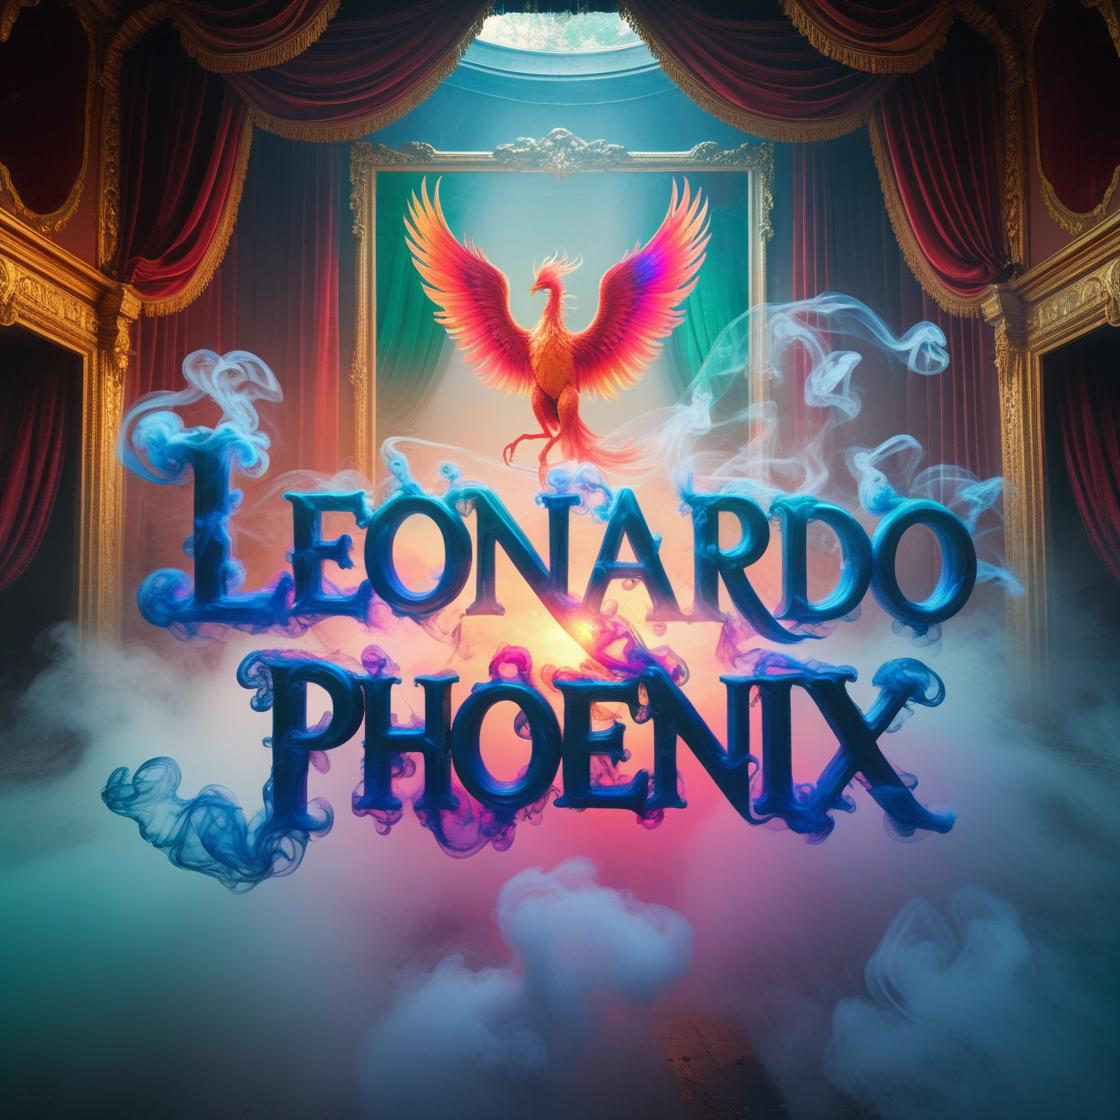

In [12]:
import base64
import io
import json

from PIL import Image

response_dict = json.loads(response_json)

# Decode the base64 image
image_data = base64.b64decode(response_dict["images"][0])

# Create a PIL image from the decoded data
image = Image.open(io.BytesIO(image_data))

# Display the image
image.show()

## 5. Clean-up

### A. Delete the endpoint, endpoint configuration, and model

In [13]:
print("🧹 Cleaning up resources...")

print("🔌 Deleting endpoint...")
model.sagemaker_session.delete_endpoint(endpoint_name)

print("⚙️ Deleting endpoint configuration...")
model.sagemaker_session.delete_endpoint_config(endpoint_name)

print("🗑️ Deleting model...")
model.delete_model()

print("✅ Cleanup completed successfully!")

🧹 Cleaning up resources...
🔌 Deleting endpoint...


⚙️ Deleting endpoint configuration...
🗑️ Deleting model...
✅ Cleanup completed successfully!


### B. Unsubscribe to the listing (optional)

If you would like to unsubscribe to the model package, follow these steps. Before you cancel the subscription, ensure that you do not have any [deployable model](https://console.aws.amazon.com/sagemaker/home#/models) created from the model package or using the algorithm. Note - You can find this information by looking at the container name associated with the model. 

**Steps to unsubscribe to product from AWS Marketplace**:
1. Navigate to __Machine Learning__ tab on [__Your Software subscriptions page__](https://aws.amazon.com/marketplace/ai/library?productType=ml&ref_=mlmp_gitdemo_indust)
2. Locate the listing that you want to cancel the subscription for, and then choose __Cancel Subscription__  to cancel the subscription.

